In [1]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

# Machine Learning 
## Topic: Logistic Regression — Classification from First Principles

**Prerequisites you already have:** Python, Linear Algebra, and Day 1's Linear Regression (hypothesis function, MSE loss, gradient descent, train/test split, evaluation with scikit-learn)

---
### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain what a classification problem is and why linear regression is the wrong tool for it
2. Understand and derive the sigmoid (logistic) function
3. Explain the decision boundary and how probabilities become class predictions
4. Understand and derive the Binary Cross-Entropy (Log Loss) function
5. Understand gradient descent for logistic regression
6. Implement logistic regression **from scratch** using only NumPy
7. Implement logistic regression using **scikit-learn**
8. Evaluate a classifier using accuracy, precision, recall, F1-score, confusion matrix
9. Understand why "accuracy" alone can be misleading


# Part 1: What is Classification, and Why Not Just Use Linear Regression?

Recall from Day 1: **regression** predicts a continuous number (e.g., exam score, house price).

**Classification** predicts a **category/class** instead. The simplest case is **binary classification** — only two possible outcomes.

| Problem | Input | Output (classes) |
|---|---|---|
| Will a student pass or fail? | Hours studied | Pass (1) / Fail (0) |
| Is this email spam? | Email text features | Spam (1) / Not Spam (0) |
| Does a patient have the disease? | Test results | Disease (1) / No Disease (0) |
| Will a customer churn? | Usage data | Churn (1) / Stay (0) |

We label the two classes as **0** and **1** (this is just a convention — "1" usually means the thing we're trying to detect/predict).

### Today's running example
We'll predict whether a student **passes (1)** or **fails (0)** an exam, based on **hours studied**.

## Why can't we just reuse Linear Regression here?

Let's actually try it and see what goes wrong. This will motivate everything else in today's lecture.


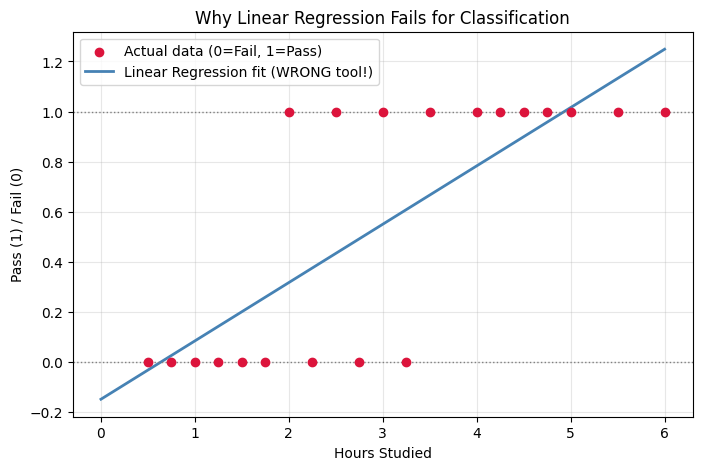

Problems visible in this plot:
1. The line predicts values below 0 and above 1 -- but probabilities must be between 0 and 1!
2. A straight line doesn't naturally model a 0/1 'jump' -- real class boundaries are more like a step or S-curve.
3. Outliers (e.g. a very high 'hours studied' student) would badly distort the whole line.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a simple pass/fail dataset
np.random.seed(42)
hours = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75,
                   3.0, 3.25, 3.5, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5, 6.0])
# Roughly: students who studied more are more likely to pass (1), but not a hard cutoff
passed = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
                    1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

plt.figure(figsize=(8, 5))
plt.scatter(hours, passed, color='crimson', zorder=3, label='Actual data (0=Fail, 1=Pass)')

# Now let's fit an ordinary LINEAR regression line to this data, just to see what happens
w_lin = np.polyfit(hours, passed, 1)[0] #degree-1 polynomial
b_lin = np.polyfit(hours, passed, 1)[1]
#Or in one line: w_lin, b_lin = np.polyfit(hours, passed, 1)
x_line = np.linspace(0, 6, 100)
y_line = w_lin * x_line + b_lin
plt.plot(x_line, y_line, color='steelblue', linewidth=2, label='Linear Regression fit (WRONG tool!)')

plt.axhline(y=0, color='gray', linestyle=':', linewidth=1)
plt.axhline(y=1, color='gray', linestyle=':', linewidth=1)
plt.title("Why Linear Regression Fails for Classification")
plt.xlabel("Hours Studied")
plt.ylabel("Pass (1) / Fail (0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Problems visible in this plot:")
print("1. The line predicts values below 0 and above 1 -- but probabilities must be between 0 and 1!")
print("2. A straight line doesn't naturally model a 0/1 'jump' -- real class boundaries are more like a step or S-curve.")
print("3. Outliers (e.g. a very high 'hours studied' student) would badly distort the whole line.")


### The problem, summarized

Linear regression outputs **any real number** ($-\infty$ to $+\infty$), but for classification we want to output a **probability** — a number strictly between **0 and 1** (e.g., "80% chance this student passes").

We need a function that:
1. Takes any real number as input (our familiar $wx + b$)
2. **Squashes** it into the range $(0, 1)$
3. Produces an **S-shaped curve** so that predictions smoothly transition from "definitely class 0" to "definitely class 1"

This function is the **sigmoid function**.


# Part 2: The Sigmoid Function

## Definition

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Where:
- $z$ is any real number (in our case, $z = wx + b$, exactly the same linear expression as Day 1!)
- $e$ is Euler's number ($\approx 2.71828$)
- $\sigma(z)$ (sigma of z) is the output, always between 0 and 1

## Why does this formula squash values into (0, 1)? Let's reason through it:

- If $z$ is a **large positive** number (e.g., $z = 10$): $e^{-z}$ becomes tiny (close to 0), so $\sigma(z) \approx \frac{1}{1+0} = 1$
- If $z$ is a **large negative** number (e.g., $z = -10$): $e^{-z}$ becomes huge, so $\sigma(z) \approx \frac{1}{1+\text{huge}} \approx 0$
- If $z = 0$: $e^{0} = 1$, so $\sigma(0) = \frac{1}{1+1} = 0.5$ exactly in the middle

So as $z$ ranges from $-\infty$ to $+\infty$, $\sigma(z)$ smoothly ranges from $0$ to $1$, always passing through exactly $0.5$ at $z=0$. This creates the characteristic **S-shaped curve**.

## The Full Logistic Regression Model

$$
z = wx + b \quad \text{(exact same linear part as Day 1 linear regression!)}
$$
$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-(wx+b)}}
$$

Here $\hat{y}$ is interpreted as: **"the probability that the class is 1"**, i.e. $\hat{y} = P(y=1 \mid x)$.

**Key insight:** Logistic Regression is just Linear Regression's output passed through the sigmoid squashing function. Everything you learned on Day 1 about $w$, $b$, and the linear combination of features still applies directly here.


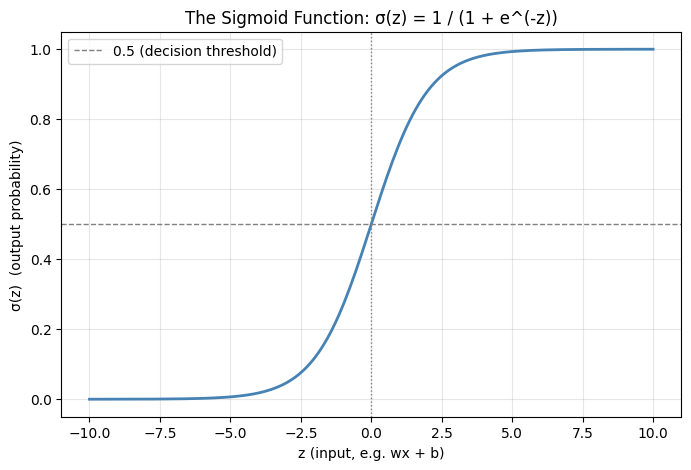

sigmoid(-10) = 0.000045  (very close to 0)
sigmoid(0)   = 0.500000  (exactly 0.5)
sigmoid(10)  = 0.999955  (very close to 1)


In [3]:
# Let's plot the sigmoid function itself to see the S-curve clearly

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid_values, color='steelblue', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='0.5 (decision threshold)')
plt.axvline(x=0, color='gray', linestyle=':', linewidth=1)
plt.title("The Sigmoid Function: σ(z) = 1 / (1 + e^(-z))")
plt.xlabel("z (input, e.g. wx + b)")
plt.ylabel("σ(z)  (output probability)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Verify our reasoning with actual numbers
print(f"sigmoid(-10) = {sigmoid(-10):.6f}  (very close to 0)")
print(f"sigmoid(0)   = {sigmoid(0):.6f}  (exactly 0.5)")
print(f"sigmoid(10)  = {sigmoid(10):.6f}  (very close to 1)")


# Part 3: From Probability to Class Prediction — The Decision Boundary

Our model outputs a **probability** $\hat{y}$ between 0 and 1. But at the end, we usually need an actual **class label** (0 or 1). We convert probability to class using a **threshold**, typically **0.5**:

$$
\text{predicted class} =
\begin{cases}
1 & \text{if } \hat{y} \geq 0.5 \\
0 & \text{if } \hat{y} < 0.5
\end{cases}
$$

Since $\sigma(z) = 0.5$ exactly when $z = 0$, this means:

$$
\text{predicted class} = 1 \iff wx + b \geq 0
$$

The point where $wx + b = 0$ is called the **decision boundary** — the "dividing line" between predicting class 0 and class 1. For one feature, this is a single point on the x-axis (the "hours studied" value above which we predict Pass). For two features, it becomes a line; for more features, a hyperplane (again, linear algebra!).

### Important note on the threshold
0.5 is the *default* threshold, but it's not fixed forever. In some real applications (e.g., detecting a serious disease), we might lower the threshold to 0.3 so we catch more true positive cases, even if it means more false alarms. 

# Part 4: Why Can't We Reuse MSE? — Binary Cross-Entropy Loss

On Day 1, we used **MSE** as our loss function for Linear Regression. A natural question: why not use MSE for Logistic Regression too?

**The problem:** When MSE is combined with the sigmoid function, the resulting loss surface is **not convex** (it has many bumpy hills and valleys, not one smooth bowl). This means gradient descent can get stuck in a **local minimum** instead of finding the actual best solution. We need a different loss function specifically designed for probabilities.

---

## Mathematical Derivation of Binary Cross-Entropy Loss

* For binary classification we have $y = 0, 1$

$$\text{If } y = 1 \implies P(y=1|x) = \hat{y}$$
$$\text{If } y = 0 \implies P(y=0|x) = (1 - \hat{y})$$

#### Combined $\implies P(y|x)$
Can be written as a single expression using exponents:
$$P(y|x) = \hat{y}^y \cdot (1 - \hat{y})^{(1 - y)}$$

Let's double-check how this beautiful shortcut works:
$$\text{If } y = 1 \implies P(y|x) = \hat{y}^1 \cdot (1 - \hat{y})^0 = \hat{y}$$
$$\text{If } y = 0 \implies P(y|x) = \hat{y}^0 \cdot (1 - \hat{y})^1 = (1 - \hat{y})$$

---

### Step 1: Taking the Logarithm
To find the best model weights, we need to maximize the total probability across our data. However, multiplying long chains of decimals causes numbers to shrink to zero, which breaks computers. 

To fix this, we take the log because the log converts dangerous multiplications into clean, safe additions:

$$\log P(y|x) = \log \left( \hat{y}^y \cdot (1 - \hat{y})^{(1 - y)} \right)$$

Using log properties ($\log(A \cdot B) = \log A + \log B$ and $\log A^b = b \log A$), the exponents drop down:
$$\log P(y|x) = y \log \hat{y} + (1 - y) \log (1 - \hat{y})$$

---

### Step 2: Flipping to a "Loss" Function
We want to maximize this log probability, but machine learning optimization algorithms are designed to minimize an error score. To turn this into a **Loss Function** that we can minimize, we multiply the entire equation by $-1$:

$$\therefore L(\hat{y}, y) = - \log P(y|x) = - \big[ y \log \hat{y} + (1 - y) \log (1 - \hat{y}) \big]$$

---

## Let's Break Down the Intuition, Case by Case:

**Case 1: True label $y = 1$** (The actual answer is "Yes")
The second term has a $(1-1)=0$ multiplier and completely vanishes, simplifying to:
$$L = -\log(\hat{y})$$
* If our model correctly predicts $\hat{y}$ close to 1 (confident & correct) $\to -\log(1) = 0 \to$ **loss ≈ 0** (no penalty).
* If our model wrongly predicts $\hat{y}$ close to 0 (confident but WRONG) $\to -\log(\text{tiny}) \to \infty \to$ **loss → huge penalty!**

**Case 2: True label $y = 0$** (The actual answer is "No")
The first term has a $y=0$ multiplier and completely vanishes, simplifying to:
$$L = -\log(1-\hat{y})$$
* If our model correctly predicts $\hat{y}$ close to 0 (confident & correct) $\to -\log(1 - 0) = 0 \to$ **loss ≈ 0** (no penalty).
* If our model wrongly predicts $\hat{y}$ close to 1 (confident but WRONG) $\to -\log(\text{tiny}) \to \infty \to$ **loss → huge penalty!**

> **Key Takeaway:** Cross-entropy loss **harshly punishes confident, wrong predictions** far more than MSE would. Predicting a 99% probability for the wrong class is penalized exponentially, which is exactly what a probability-based model needs to learn efficiently.

---

## Total Loss Over the Whole Dataset

To evaluate our model across all $m$ examples in our dataset, we simply take the average of our single-point losses:

$$J(w,b) = -\frac{1}{m} \sum_{i=1}^{m} \big[ y_i \log \hat{y}_i + (1 - y_i) \log (1 - \hat{y}_i) \big]$$

This is exactly what `scikit-learn` (and virtually every modern machine learning framework) minimizes internally when training a logistic regression model.

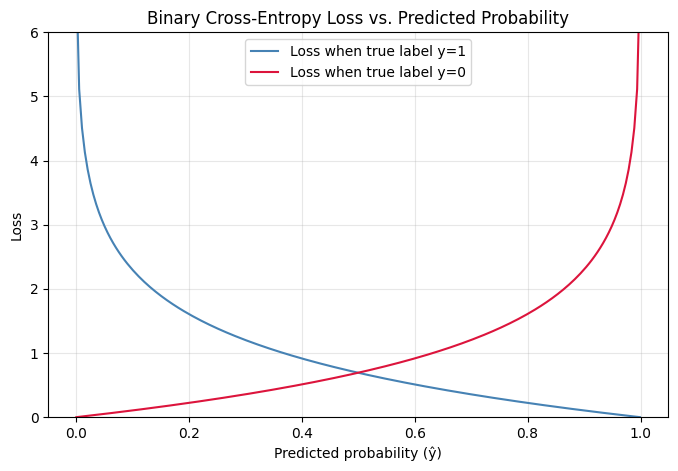

Notice: each curve shoots up towards infinity as the prediction gets confidently WRONG.
E.g., if true label is 1 but model predicts ŷ=0.01 (99% sure it's 0), the loss is huge.


In [4]:
# Let's visualize WHY cross-entropy punishes confident wrong answers so harshly,
# compared to how gentle it is when the prediction is confident AND correct.

y_hat_range = np.linspace(0.001, 0.999, 200)  # avoid exactly 0 or 1 (log undefined there)

loss_if_true_label_is_1 = -np.log(y_hat_range)
loss_if_true_label_is_0 = -np.log(1 - y_hat_range)

plt.figure(figsize=(8, 5))
plt.plot(y_hat_range, loss_if_true_label_is_1, color='steelblue', label='Loss when true label y=1')
plt.plot(y_hat_range, loss_if_true_label_is_0, color='crimson', label='Loss when true label y=0')
plt.title("Binary Cross-Entropy Loss vs. Predicted Probability")
plt.xlabel("Predicted probability (ŷ)")
plt.ylabel("Loss")
plt.ylim(0, 6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice: each curve shoots up towards infinity as the prediction gets confidently WRONG.")
print("E.g., if true label is 1 but model predicts ŷ=0.01 (99% sure it's 0), the loss is huge.")


# Part 5: Gradient Descent for Logistic Regression

Just like Day 1, we use **gradient descent** to find the $w, b$ that minimize the loss $J(w,b)$.

## The gradients (derived using calculus - chain rule through the sigmoid and log terms)

Remarkably, after all the calculus simplifies, the gradients have the **exact same form** as linear regression's gradients:

$$
\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)\cdot x_i
$$
$$
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)
$$

The **only difference** from Day 1 is that $\hat{y}_i$ here is $\sigma(wx_i + b)$ (a probability from the sigmoid), instead of $wx_i + b$ directly.

## Update rule (identical structure to Day 1)

$$
w := w - \alpha \cdot \frac{\partial J}{\partial w}, \qquad b := b - \alpha \cdot \frac{\partial J}{\partial b}
$$

Same idea as before: take small steps ($\alpha$ = learning rate) in the direction that reduces the loss, repeated over many epochs.

**This is why Day 1 was essential preparation** — logistic regression reuses the entire gradient descent machinery; only the model's output (sigmoid) and the loss function (cross-entropy) changed.


## The Complete Mathematical Proof: Why Gradients Match

To understand how the Chain Rule applies here without needing a neural network, let's trace our forward math step-by-step for a single data point:

1. **The Linear Line:** $z = wx + b$
2. **The Sigmoid Prediction:** $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$
3. **The Loss Function:** $L = -\big[ y \log \hat{y} + (1 - y) \log(1 - \hat{y}) \big]$

We want to know how a tiny change in our weight ($w$) affects our final Loss ($L$). In calculus, this is written as $\frac{\partial L}{\partial w}$. 

Because $w$ changes $z$, $z$ changes $\hat{y}$, and $\hat{y}$ changes $L$, the **Chain Rule** tells us we can multiply their individual rates of change together:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$$

Let's solve these three pieces one by one.

---

### Step 1: Derivative of Loss with respect to Prediction $\left(\frac{\partial L}{\partial \hat{y}}\right)$

Our loss equation is:  
$L = -y \log \hat{y} - (1 - y) \log(1 - \hat{y})$

Remember from calculus that the derivative of $\log(x)$ is $\frac{1}{x}$, and using the chain rule for $\log(1-x)$ gives $\frac{-1}{1-x}$. Let's take the derivative with respect to $\hat{y}$:

$$\frac{\partial L}{\partial \hat{y}} = -y \left(\frac{1}{\hat{y}}\right) - (1 - y) \left(\frac{-1}{1 - \hat{y}}\right)$$

$$\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1 - y}{1 - \hat{y}}$$

Let's combine these into a single fraction by finding a common denominator:

$$\frac{\partial L}{\partial \hat{y}} = \frac{-y(1 - \hat{y}) + \hat{y}(1 - y)}{\hat{y}(1 - \hat{y})}$$

$$\frac{\partial L}{\partial \hat{y}} = \frac{-y + y\hat{y} + \hat{y} - y\hat{y}}{\hat{y}(1 - \hat{y})}$$

$$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$

---

### Step 2: Derivative of Sigmoid with respect to the Line $\left(\frac{\partial \hat{y}}{\partial z}\right)$

Our prediction equation is:  
$$\hat{y} = (1 + e^{-z})^{-1}$$

Using the power rule and chain rule from calculus:

$$\frac{\partial \hat{y}}{\partial z} = -1(1 + e^{-z})^{-2} \cdot \left(e^{-z} \cdot -1\right)$$

$$\frac{\partial \hat{y}}{\partial z} = \frac{e^{-z}}{(1 + e^{-z})^2}$$

Let's split this fraction apart using a clever algebra trick:

$$\frac{\partial \hat{y}}{\partial z} = \left(\frac{1}{1 + e^{-z}}\right) \cdot \left(\frac{e^{-z}}{1 + e^{-z}}\right)$$

Notice that $\frac{1}{1 + e^{-z}}$ is exactly our definition of $\hat{y}$. Also, notice that $\frac{e^{-z}}{1 + e^{-z}}$ can be rewritten as $\frac{1 + e^{-z} - 1}{1 + e^{-z}} = 1 - \hat{y}$. 

Therefore, the derivative of the Sigmoid function simplifies beautifully to:
$$\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$$

---

### Step 3: Derivative of the Line with respect to Weight $\left(\frac{\partial z}{\partial w}\right)$

Our line equation is:  
$z = wx + b$

Taking the derivative with respect to $w$ treats $b$ as a constant ($0$) and leaves us with just:
$$\frac{\partial z}{\partial w} = x$$

*(Note: If we took the derivative with respect to the bias $b$, $\frac{\partial z}{\partial b} = 1$)*

---

### Step 4: Multiplying It All Together (The Big Magic Trick)

Now we assemble our Chain Rule puzzle pieces:

$$\frac{\partial L}{\partial w} = \color{crimson}{\frac{\partial L}{\partial \hat{y}}} \cdot \color{steelblue}{\frac{\partial \hat{y}}{\partial z}} \cdot \color{forestgreen}{\frac{\partial z}{\partial w}}$$

$$\frac{\partial L}{\partial w} = \color{crimson}{\left( \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} \right)} \cdot \color{steelblue}{\Big( \hat{y}(1 - \hat{y}) \Big)} \cdot \color{forestgreen}{x}$$

Look closely! The denominator $\hat{y}(1 - \hat{y})$ from the loss derivative perfectly cancels out the entire sigmoid derivative multiplying it!

$$\frac{\partial L}{\partial w} = (\hat{y} - y) \cdot x$$

---

### Final Global Loss Gradient $J(w,b)$

Because our total dataset loss $J(w,b)$ is simply the average of all single-point losses ($J = \frac{1}{m}\sum L$), we sum up this result for all $m$ examples:

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)\cdot x_i$$

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)$$

## Let's implement Logistic Regression completely from scratch (NumPy only)

We'll use our small pass/fail dataset from earlier.


In [5]:
# From-scratch Logistic Regression using Gradient Descent

X = hours.copy()     # hours studied (our single feature)
y = passed.copy()    # true labels: 0 = Fail, 1 = Pass
m = len(X)

# Initialize parameters
w = 0.0
b = 0.0

learning_rate = 0.1
epochs = 5000
loss_history = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    # ---- Forward pass ----
    z = w * X + b
    y_hat = sigmoid(z)   # predicted probabilities

    # ---- Compute Binary Cross-Entropy Loss ----
    # small epsilon added to avoid log(0), which is undefined
    eps = 1e-9
    loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    loss_history.append(loss)

    # ---- Compute gradients (same form as linear regression!) ----
    dw = (1/m) * np.sum((y_hat - y) * X)
    db = (1/m) * np.sum((y_hat - y))

    # ---- Update parameters ----
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | w = {w:.4f} | b = {b:.4f}")

print(f"\nFinal learned parameters: w = {w:.4f}, b = {b:.4f}")

# What hours-studied value is our decision boundary? (where wx + b = 0)
decision_boundary = -b / w
print(f"Decision boundary: students need to study more than {decision_boundary:.2f} hours to be predicted as 'Pass'")


Epoch    0 | Loss: 0.6931 | w = 0.0750 | b = 0.0050
Epoch  500 | Loss: 0.3354 | w = 1.2320 | b = -3.0692
Epoch 1000 | Loss: 0.3145 | w = 1.5512 | b = -4.0109
Epoch 1500 | Loss: 0.3094 | w = 1.7119 | b = -4.4765
Epoch 2000 | Loss: 0.3078 | w = 1.8047 | b = -4.7433
Epoch 2500 | Loss: 0.3072 | w = 1.8617 | b = -4.9069
Epoch 3000 | Loss: 0.3070 | w = 1.8981 | b = -5.0107
Epoch 3500 | Loss: 0.3069 | w = 1.9217 | b = -5.0782
Epoch 4000 | Loss: 0.3068 | w = 1.9372 | b = -5.1225
Epoch 4500 | Loss: 0.3068 | w = 1.9475 | b = -5.1518

Final learned parameters: w = 1.9544, b = -5.1714
Decision boundary: students need to study more than 2.65 hours to be predicted as 'Pass'


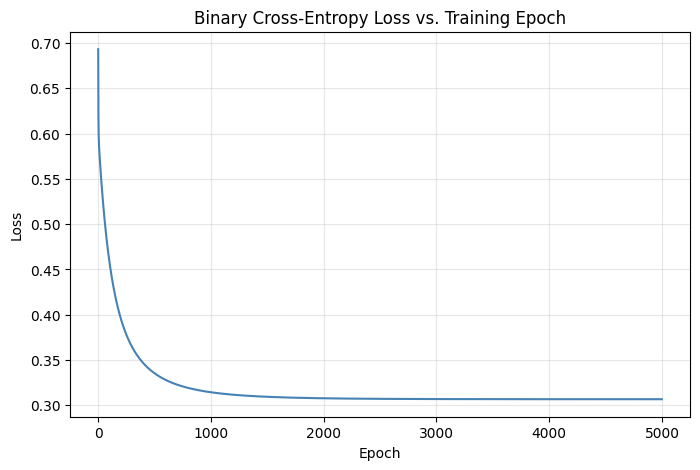

In [6]:
# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='steelblue')
plt.title("Binary Cross-Entropy Loss vs. Training Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()


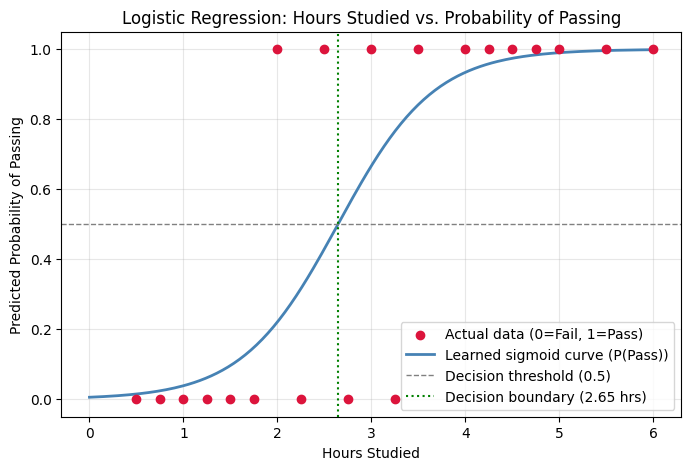

Notice the S-shape: low hours -> probability near 0, high hours -> probability near 1,
with a smooth transition around the decision boundary -- unlike the straight line from linear regression!


In [7]:
# Plot the learned sigmoid curve against our actual data points
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='crimson', zorder=3, label='Actual data (0=Fail, 1=Pass)')

x_line = np.linspace(0, 6, 200)
y_line = sigmoid(w * x_line + b)
plt.plot(x_line, y_line, color='steelblue', linewidth=2, label='Learned sigmoid curve (P(Pass))')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
plt.axvline(x=decision_boundary, color='green', linestyle=':', linewidth=1.5, label=f'Decision boundary ({decision_boundary:.2f} hrs)')

plt.title("Logistic Regression: Hours Studied vs. Probability of Passing")
plt.xlabel("Hours Studied")
plt.ylabel("Predicted Probability of Passing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice the S-shape: low hours -> probability near 0, high hours -> probability near 1,")
print("with a smooth transition around the decision boundary -- unlike the straight line from linear regression!")
